# 3B - Alvo, eventos e ciclo de vida (NOAA/ONI local)

**Pergunta especifica.** Como os eventos El Nino locais, definidos pela regra NOAA/ONI compativel, nascem, crescem, picam e decaem nas classes `fraco`, `moderado`, `forte` e `muito_forte`? E onde comeca e termina a FAIXA de pico de cada evento?

**Objetivo.** Caracterizar duracao, crescimento, decaimento, persistencia e trajetorias compostas usando a media movel de 3 meses da SSTA Nino 3.4 e os limiares NOAA de intensidade; delimitar o pico como janela (faixa), nao como ponto.

**Justificativa.** A Fase 3 adota a definicao NOAA/ONI local. O evento exige SSTA Nino 3.4 >=+0.5 C em 5 estacoes moveis de 3 meses, e a intensidade vem do pico dessa media movel. O pico pontual e instavel a ruido intrassazonal; a fundamentacao bibliografica da faixa de pico esta em `docs/PICO_FAIXA_BIBLIOGRAFIA.md`.

**Metodologia.** Eventos = media movel de 3 meses >=+0.5 C por 5+ estacoes sobrepostas na base OISST local. Classes NOAA: fraco [0.5,1.0), moderado [1.0,1.5), forte [1.5,2.0), muito_forte >=2.0 C. Trajetorias alinhadas ao pico; autocorrelacao semanal 1-78 lags; faixa de pico = meses com ONI local >= pico - 0.1 C; mapa composto dos eventos `muito_forte`.

**Saidas.** `phase3B_eventos_taxas.csv`, `phase3B_trajetorias_compostas.csv`, `phase3B_grupos_classes_noaa.csv`, `phase3B_autocorrelacao.csv`, `phase3B_memoria_persistencia.csv`, `phase3B_faixa_pico_eventos.csv`, `phase3B_mapa_composto_resumo.csv` + figuras `3B1`-`3B4`.


In [1]:
import sys; sys.path.insert(0,'.')
import numpy as np, pandas as pd, matplotlib.pyplot as plt, xarray as xr
import fase3_utils as u
weekly=pd.read_csv(u.FEAT/'phase3_indices_semanais.csv',parse_dates=['week_ending_sunday']).set_index('week_ending_sunday')
ev=u.events_noaa().copy()
ssta=weekly['nino34_ssta']
rows=[]
for _,e in ev.iterrows():
    don=(e.peak_time-e.event_start).days/30.44; doff=(e.event_end-e.peak_time).days/30.44
    s0,sp,s1=ssta.asof(e.event_start),ssta.asof(e.peak_time),ssta.asof(e.event_end)
    rows.append({'event_id':e.event_id,'classe':e.classe_noaa,'oni_pico_c':round(e.peak_oni_local_c if 'peak_oni_local_c' in e else e.peak_ssta_c,3),'ssta_mensal_pico_c':round(e.peak_monthly_ssta_c,3),'duracao_estacoes_oni':e.duration_oni_seasons if 'duration_oni_seasons' in e else e.duration_months,
     'crescimento_c_por_mes':round((sp-s0)/max(don,1e-9),3),'decaimento_c_por_mes':round((s1-sp)/max(doff,1e-9),3),
     'limiar_evento_oni_c':0.5,'criterio_temporal':'5+ estacoes moveis de 3 meses'})
taxas=pd.DataFrame(rows); u.save_table(taxas,'phase3B_eventos_taxas.csv',index=False)
print('eventos elegiveis NOAA/ONI local =',len(ev)); taxas


[tabela] data/processed/parquet/statistics/phase3B_eventos_taxas.csv
eventos elegiveis NOAA/ONI local = 12


,event_id,classe,oni_pico_c,ssta_mensal_pico_c,duracao_estacoes_oni,crescimento_c_por_mes,decaimento_c_por_mes,limiar_evento_oni_c,criterio_temporal
0,el_nino_oisst_1982_1983,muito_forte,2.120,2.213,11,0.306,-0.470,0.5,5+ estacoes moveis de 3 meses
1,el_nino_oisst_1986_1988,moderado,1.211,1.223,16,0.048,-0.048,0.5,5+ estacoes moveis de 3 meses
2,el_nino_oisst_1991_1992,forte,1.625,1.736,10,0.325,-0.167,0.5,5+ estacoes moveis de 3 meses
3,el_nino_oisst_1994_1995,fraco,0.968,1.192,5,0.428,-0.251,0.5,5+ estacoes moveis de 3 meses
4,el_nino_oisst_1997_1998,muito_forte,2.146,2.166,11,0.241,-0.249,0.5,5+ estacoes moveis de 3 meses
5,el_nino_oisst_2002_2003,moderado,1.213,1.250,8,0.173,-0.148,0.5,5+ estacoes moveis de 3 meses
6,el_nino_oisst_2004,fraco,0.652,0.681,5,-0.051,-0.037,0.5,5+ estacoes moveis de 3 meses
7,el_nino_oisst_2006_2007,fraco,0.920,1.128,5,0.164,0.204,0.5,5+ estacoes moveis de 3 meses
8,el_nino_oisst_2009_2010,forte,1.586,1.719,10,0.172,-0.149,0.5,5+ estacoes moveis de 3 meses
9,el_nino_oisst_2014_2016,muito_forte,2.592,2.448,19,0.188,-0.382,0.5,5+ estacoes moveis de 3 meses


[tabela] data/processed/parquet/statistics/phase3B_trajetorias_compostas.csv
[tabela] data/processed/parquet/statistics/phase3B_grupos_classes_noaa.csv


[figura] data/processed/figures/fase3/3B1_trajetorias_compostas.png


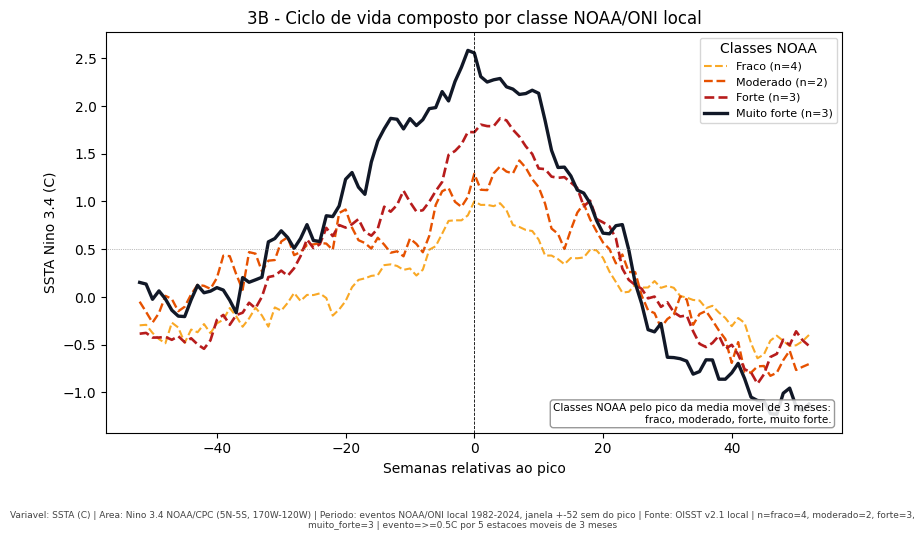

In [2]:
lags=list(range(-52,53))
groups=u.elnino_mean_groups(ev)

def peak_aligned(series,e):
    i=series.index.get_indexer([e.peak_time],method='nearest')[0]
    seg=series.iloc[max(0,i-52):i+53]
    rel=((seg.index-series.index[i]).days/7).round().astype(int)
    return pd.Series(seg.values,index=rel).reindex(lags)

comp={}
for grupo,gg in groups.items():
    frames=[peak_aligned(ssta,e) for _,e in gg.iterrows()]
    comp[grupo]=pd.DataFrame(frames).mean() if frames else pd.Series(index=lags,dtype=float)
comp=pd.DataFrame({g:comp[g] for g in u.ELNINO_MEAN_GROUP_ORDER})
u.save_table(comp.rename_axis('semana_rel_pico'),'phase3B_trajetorias_compostas.csv')
u.save_table(u.elnino_mean_group_table()[['grupo','rotulo','definicao']],'phase3B_grupos_classes_noaa.csv',index=False)
fig,ax=plt.subplots(figsize=(9.5,5.2))
for grupo in u.ELNINO_MEAN_GROUP_ORDER:
    if len(groups[grupo]) == 0: continue
    meta=u.elnino_group_style(grupo)
    label=f"{meta['rotulo_curto']} (n={len(groups[grupo])})"
    ax.plot(comp.index,comp[grupo],label=label,color=meta['color'],lw=meta['linewidth'],ls=meta['linestyle'])
ax.axvline(0,color='k',ls='--',lw=.6); ax.axhline(.5,color='grey',ls=':',lw=.5); ax.legend(fontsize=8,title='Classes NOAA')
ax.set_xlabel('Semanas relativas ao pico'); ax.set_ylabel('SSTA Nino 3.4 (C)'); ax.set_title('3B - Ciclo de vida composto por classe NOAA/ONI local')
u.add_note(ax, 'Classes NOAA pelo pico da media movel de 3 meses:\nfraco, moderado, forte, muito forte.', loc='lower right')
counts=ev['classe_noaa'].value_counts().to_dict()
u.stamp_caption(fig,variavel='SSTA (C)',area=u.CAIXAS['nino34'],periodo='eventos NOAA/ONI local 1982-2024, janela +-52 sem do pico',
 fonte='OISST v2.1 local',n=', '.join(f"{k}={counts.get(k,0)}" for k in u.ELNINO_MEAN_GROUP_ORDER),extra='evento=>=0.5C por 5 estacoes moveis de 3 meses')
u.save_fig(fig,'3B1_trajetorias_compostas.png'); plt.show()


[tabela] data/processed/parquet/statistics/phase3B_autocorrelacao.csv
[tabela] data/processed/parquet/statistics/phase3B_memoria_persistencia.csv


[figura] data/processed/figures/fase3/3B2_autocorrelacao.png
efold = 27 | genese antes do onset 24.6 sem | crescimento medio 22.9 sem | decaimento medio 16.7 sem


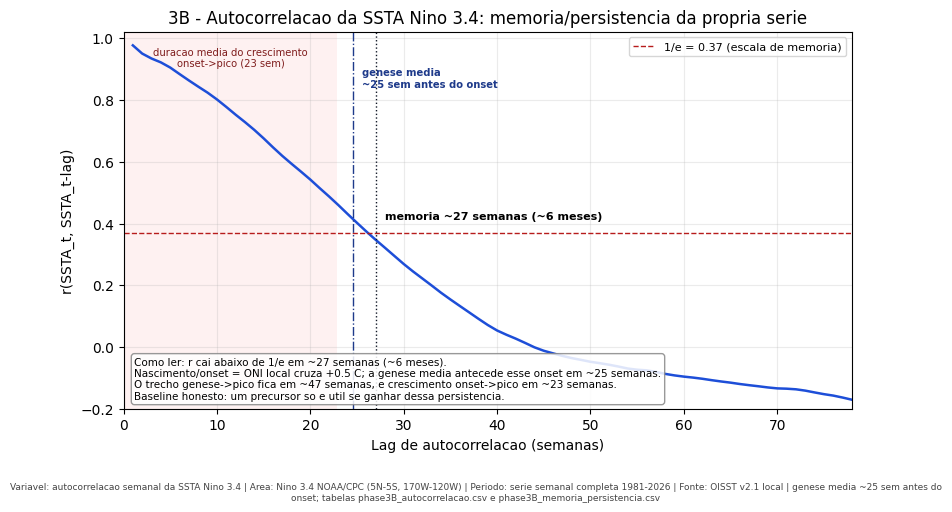

In [3]:
# ---------- 3B2: autocorrelacao com leitura fisica ----------
ac = pd.Series({lag: ssta.autocorr(lag) for lag in range(1, 79)}, name='autocorrelacao')
below = ac[ac < 1/np.e]
efold = int(below.index.min()) if len(below) else np.nan
mem = ac.to_frame()
mem['abaixo_1_sobre_e'] = ac < 1/np.e
mem['interpretacao'] = 'memoria da SSTA ainda relevante'
mem.loc[mem['abaixo_1_sobre_e'], 'interpretacao'] = 'memoria caiu abaixo de 1/e'
u.save_table(mem, 'phase3B_autocorrelacao.csv')
onset_med = float(np.mean([(e.event_start - e.peak_time).days/7 for _, e in ev.iterrows()]))
fim_med = float(np.mean([(e.event_end - e.peak_time).days/7 for _, e in ev.iterrows()]))
dur_med = float(np.mean([(e.event_end - e.event_start).days/7 for _, e in ev.iterrows()]))
life_path = u.STATS/'phase3_event_lifecycle_en_ln.csv'
if life_path.exists():
    life = pd.read_csv(life_path)
    fase_dur = life[life['tipo'].eq('el_nino')].groupby('fase')['duracao_semanas'].mean().to_dict()
else:
    fase_dur = {}
genese_pre_onset = float(fase_dur.get('genese', 26.0))
genese_ate_pico = genese_pre_onset + (-onset_med)
resumo = pd.DataFrame([{
    'escala_memoria_1_sobre_e_semanas': efold,
    'equivalente_meses': round(efold/4.345, 1),
    'duracao_media_evento_el_nino_semanas': round(dur_med, 1),
    'crescimento_medio_onset_ate_pico_semanas': round(-onset_med, 1),
    'decaimento_medio_pico_ate_fim_semanas': round(fim_med, 1),
    'genese_media_antes_onset_semanas': round(genese_pre_onset, 1),
    'genese_media_inicio_ate_pico_semanas': round(genese_ate_pico, 1),
    'leitura': ('a SSTA Nino 3.4 guarda memoria util por ~meio ano (~2 estacoes ONI); '
                'isso equivale aproximadamente a duracao da fase de crescimento (onset->pico) de um evento. '
                'Qualquer precursor da Fase 5 so agrega valor se superar essa persistencia.'),
}])
u.save_table(resumo, 'phase3B_memoria_persistencia.csv', index=False)

fig, ax = plt.subplots(figsize=(9.4, 4.9))
ax.plot(ac.index, ac.values, color='#1d4ed8', lw=1.8)
ax.axhline(1/np.e, ls='--', color='#b71c1c', lw=1, label='1/e = 0.37 (escala de memoria)')
if np.isfinite(efold):
    ax.axvline(efold, ls=':', color='#111827', lw=1)
    ax.text(efold+1, 1/np.e+0.045, f'memoria ~{efold} semanas (~{efold/4.345:.0f} meses)', fontsize=8, weight='bold')
ax.axvspan(0, -onset_med, color='#fee2e2', alpha=.45, lw=0)
ax.axvline(genese_pre_onset, color='#1e3a8a', ls='-.', lw=1)
ax.text(-onset_med/2, .97, f'duracao media do crescimento\nonset->pico ({-onset_med:.0f} sem)', ha='center', va='top', fontsize=7.2, color='#7f1d1d')
ax.text(genese_pre_onset+1, .84, f'genese media\n~{genese_pre_onset:.0f} sem antes do onset', fontsize=7.2, color='#1e3a8a', weight='bold')
ax.set_xlabel('Lag de autocorrelacao (semanas)')
ax.set_ylabel('r(SSTA_t, SSTA_t-lag)')
ax.set_ylim(-0.2, 1.02)
ax.set_xlim(0, 78)
ax.set_title('3B - Autocorrelacao da SSTA Nino 3.4: memoria/persistencia da propria serie')
ax.grid(alpha=.25)
ax.legend(fontsize=8, loc='upper right')
u.add_note(ax, f'Como ler: r cai abaixo de 1/e em ~{efold} semanas (~{efold/4.345:.0f} meses).\nNascimento/onset = ONI local cruza +0.5 C; a genese media antecede esse onset em ~{genese_pre_onset:.0f} semanas.\nO trecho genese->pico fica em ~{genese_ate_pico:.0f} semanas, e crescimento onset->pico em ~{-onset_med:.0f} semanas.\nBaseline honesto: um precursor so e util se ganhar dessa persistencia.', loc='lower left')
u.stamp_caption(fig, variavel='autocorrelacao semanal da SSTA Nino 3.4', area=u.CAIXAS['nino34'], periodo='serie semanal completa 1981-2026', fonte='OISST v2.1 local', extra=f'genese media ~{genese_pre_onset:.0f} sem antes do onset; tabelas phase3B_autocorrelacao.csv e phase3B_memoria_persistencia.csv')
u.save_fig(fig, '3B2_autocorrelacao.png')
print('efold =', efold, '| genese antes do onset', round(genese_pre_onset,1), 'sem | crescimento medio', round(-onset_med,1), 'sem | decaimento medio', round(fim_med,1), 'sem')
plt.show()


[tabela] data/processed/parquet/statistics/phase3B_faixa_pico_eventos.csv
               event_id mes_pico faixa_inicio faixa_fim  largura_faixa_meses
el_nino_oisst_1982_1983  1983-01      1982-12   1983-01                    2
el_nino_oisst_1986_1988  1987-08      1987-08   1987-09                    2
el_nino_oisst_1991_1992  1992-01      1992-01   1992-01                    1
el_nino_oisst_1994_1995  1994-12      1994-11   1995-01                    3
el_nino_oisst_1997_1998  1997-12      1997-11   1997-12                    2
el_nino_oisst_2002_2003  2002-11      2002-11   2002-12                    2
     el_nino_oisst_2004  2004-09      2004-08   2004-12                    5
el_nino_oisst_2006_2007  2006-12      2006-11   2006-12                    2
el_nino_oisst_2009_2010  2009-12      2009-12   2010-01                    2
el_nino_oisst_2014_2016  2015-12      2015-11   2015-12                    2
el_nino_oisst_2018_2019  2018-11      2018-11   2019-04                    6
el

[figura] data/processed/figures/fase3/3B4_faixa_pico_oni.png


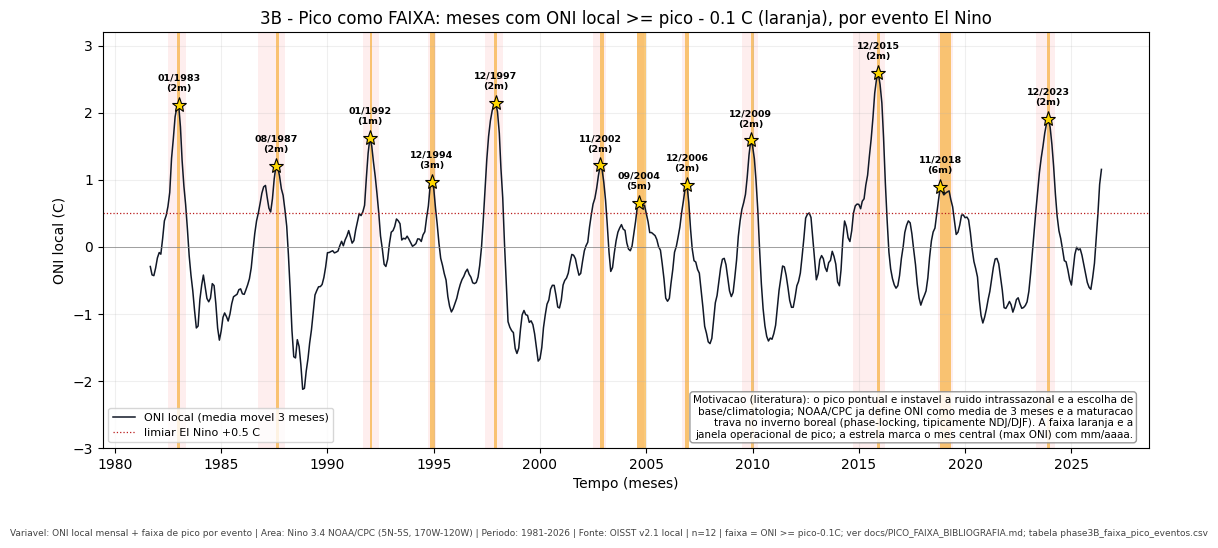

In [4]:
# ---------- 3B4: faixa de pico (pico como janela, nao como ponto) ----------
DELTA = 0.1  # tolerancia (C): incerteza tipica de indice/climatologia
daily = u.load_daily_nino34()
mon = daily['nino34_ssta'].resample('MS').mean()
oni = mon.rolling(3, center=True, min_periods=2).mean()
rows = []
for _, e in ev.iterrows():
    seg = oni.loc[e.event_start:e.event_end]
    if seg.empty: continue
    pk = float(seg.max()); tpk = seg.idxmax()
    band = seg[seg >= pk - DELTA]
    rows.append({'event_id': e.event_id, 'classe_noaa': e.classe_noaa,
                 'pico_oni_local_c': round(pk, 3), 'mes_pico': tpk.strftime('%Y-%m'),
                 'faixa_inicio': band.index.min().strftime('%Y-%m'),
                 'faixa_fim': band.index.max().strftime('%Y-%m'),
                 'largura_faixa_meses': int(round((band.index.max()-band.index.min()).days/30.44))+1,
                 'criterio': f'meses com ONI local >= pico - {DELTA} C'})
faixa = pd.DataFrame(rows)
u.save_table(faixa, 'phase3B_faixa_pico_eventos.csv', index=False)
print(faixa[['event_id','mes_pico','faixa_inicio','faixa_fim','largura_faixa_meses']].to_string(index=False))

fig, ax = plt.subplots(figsize=(13.5, 5.4))
ax.plot(oni.index, oni.values, color='#111827', lw=1.1, label='ONI local (media movel 3 meses)')
ax.axhline(0.5, color='#b91c1c', ls=':', lw=.9, label='limiar El Nino +0.5 C')
ax.axhline(0, color='0.5', lw=.5)
for _, e in ev.iterrows():
    ax.axvspan(e.event_start, e.event_end, color='#fca5a5', alpha=.18, lw=0)
for _, r in faixa.iterrows():
    i0 = pd.to_datetime(r['faixa_inicio']); i1 = pd.to_datetime(r['faixa_fim']) + pd.offsets.MonthEnd(1)
    ax.axvspan(i0, i1, color='#f59e0b', alpha=.55, lw=0)
    tpk = pd.to_datetime(r['mes_pico'])
    ax.plot(tpk, r['pico_oni_local_c'], marker='*', ms=11, mfc='#ffd700', mec='k', mew=.8, zorder=5)
    ax.annotate(f"{tpk.strftime('%m/%Y')}\n({r['largura_faixa_meses']}m)", xy=(tpk, r['pico_oni_local_c']),
                xytext=(0, 10), textcoords='offset points', ha='center', fontsize=6.8, weight='bold')
ax.set_ylim(-3, 3.2)
ax.set_xlabel('Tempo (meses)')
ax.set_ylabel('ONI local (C)')
ax.set_title(f'3B - Pico como FAIXA: meses com ONI local >= pico - {DELTA} C (laranja), por evento El Nino')
ax.legend(fontsize=8, loc='lower left')
ax.grid(alpha=.2)
u.add_note(ax, 'Motivacao (literatura): o pico pontual e instavel a ruido intrassazonal e a escolha de\nbase/climatologia; NOAA/CPC ja define ONI como media de 3 meses e a maturacao\ntrava no inverno boreal (phase-locking, tipicamente NDJ/DJF). A faixa laranja e a\njanela operacional de pico; a estrela marca o mes central (max ONI) com mm/aaaa.', loc='lower right')
u.stamp_caption(fig, variavel='ONI local mensal + faixa de pico por evento', area=u.CAIXAS['nino34'], periodo='1981-2026', fonte='OISST v2.1 local', n=str(len(faixa)), extra=f'faixa = ONI >= pico-{DELTA}C; ver docs/PICO_FAIXA_BIBLIOGRAFIA.md; tabela phase3B_faixa_pico_eventos.csv')
u.save_fig(fig, '3B4_faixa_pico_oni.png')
plt.show()


[tabela] data/processed/parquet/statistics/phase3B_mapa_composto_resumo.csv


[figura] data/processed/figures/fase3/3B3_mapa_composto_pico.png


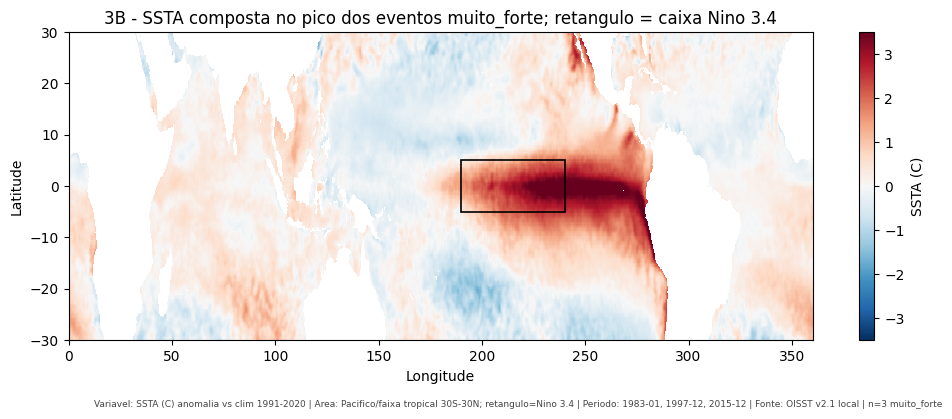

,evento,ssta_max_c,ssta_media_nino34_c
0,1983-01,5.341,2.227
1,1997-12,6.091,2.181
2,2015-12,4.284,2.461


In [5]:
MAPC=u.ROOT/'data/interim/fase3_map_cache'
def mf(y,m):
    f=MAPC/f'sst_month_{y}_{m:02d}.nc'
    if f.exists(): return xr.open_dataarray(f)
    try: ds=xr.open_zarr(u.ROOT/f'data/processed/zarr/cpc_noaa/oisst/sst.day.mean.{y}.zarr',consolidated=False)
    except Exception: ds=xr.open_dataset(u.ROOT/f'data/raw/cpc_noaa/oisst/sst.day.mean.{y}.nc')
    fld=ds['sst'].sel(time=f'{y}-{m:02d}').mean('time').sel(lat=slice(-30,30)).load(); ds.close(); return fld
super_ev=ev.query("classe_noaa == 'muito_forte'").copy()
fields=[]
for _,e in super_ev.iterrows():
    y=int(e.peak_time.year); m=int(e.peak_time.month)
    clim=xr.concat([mf(cy,m) for cy in range(1991,2021)],'y').mean('y')
    fields.append((f'{y}-{m:02d}',(mf(y,m)-clim).load()))
cf=xr.concat([f for _,f in fields],'e').mean('e')
fig,ax=plt.subplots(figsize=(12,4)); pc=ax.pcolormesh(cf.lon,cf.lat,cf.values,cmap='RdBu_r',vmin=-3.5,vmax=3.5,shading='auto')
ax.add_patch(plt.Rectangle((190,-5),50,10,fill=False,ec='k',lw=1.2)); ax.set_xlabel('Longitude'); ax.set_ylabel('Latitude')
ax.set_title('3B - SSTA composta no pico dos eventos muito_forte; retangulo = caixa Nino 3.4')
fig.colorbar(pc,ax=ax,label='SSTA (C)')
u.stamp_caption(fig,variavel='SSTA (C) anomalia vs clim 1991-2020',area='Pacifico/faixa tropical 30S-30N; retangulo=Nino 3.4',
 periodo=', '.join(pk for pk,_ in fields),fonte='OISST v2.1 local',n=f'{len(fields)} muito_forte')
res=pd.DataFrame([{'evento':pk,'ssta_max_c':round(float(f.max()),3),'ssta_media_nino34_c':round(float(f.sel(lat=slice(-5,5),lon=slice(190,240)).mean()),3)} for pk,f in fields])
u.save_table(res,'phase3B_mapa_composto_resumo.csv',index=False); u.save_fig(fig,'3B3_mapa_composto_pico.png'); plt.show(); res


**Leitura do 3B.** A Fase 3 usa a classificacao NOAA/ONI local (`fraco`..`muito_forte`) pelo pico da media movel de 3 meses. A persistencia da SSTA tem e-folding de ~27 semanas (~6 meses): a serie "lembra" de si por ~2 estacoes ONI. O nascimento/onset do El Nino e o cruzamento sustentado de +0.5 C; a genese operacional media antecede esse onset em ~26 semanas, enquanto o crescimento onset->pico dura ~23 semanas. O 3B2 agora explicita essa antecedencia media no grafico. O 3B4 materializa o pico como FAIXA (meses com ONI >= pico-0.1 C): eventos fortes tem faixa estreita (1-2 meses, phase-locked em NDJ) e eventos fracos tem faixa larga (5-6 meses; pico pontual pouco informativo). O mapa das 4 fases (genese/crescimento/pico/decaimento) para EN x LN esta em 3L.
